# GRU with SHAP-Selected Union Features

This notebook is a variant of the original temporal forecasting model with one key change: instead of using all 49 sensor + time features, the input is restricted to the **union of the top-X sensor and top-Y demographic features** ranked by CatBoost SHAP importance for SIS and OHS separately.

Everything else mirrors the accepted paper:
- **FeatureGate**: one SHAP-initialized learnable gate applied to the shared union feature set
- **GRU + DecayAttention**: shared encoder with two target-specific recency-biased attention streams
- **18-item multi-task output**: 6 SIS items (1–5 scale) + 12 OHS items (0–4 scale)
- **Patient-grouped 5-fold CV**, leakage-safe temporal splits, same metrics

Demographic features are static per patient and are repeated at every time-step so the GRU sees patient context at each day.

In [20]:
from pathlib import Path
import copy
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

TOP_X_SENSOR = 12
TOP_Y_DEMO   = 1

SEED         = 1399
FORECAST_GAP = 7
BATCH_SIZE   = 12
MAX_EPOCHS   = 500
PATIENCE     = 45
LR           = 2e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM   = 24
DROPOUT      = 0.3
DECAY_RATE   = 0.08
TOTAL_LOSS_WEIGHT = 0.0

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "mps")
DATA_DIR = Path.cwd()
SHAP_DIR = DATA_DIR /f"catboost-shap{SEED}"

sis_targets = [f"sis-{i:02d}" for i in range(1, 7)]
ohs_targets = [f"ohs-{i:02d}" for i in range(1, 13)]

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
plt.style.use("ggplot")
print(f"Device: {DEVICE}")
print(f"TOP_X_SENSOR={TOP_X_SENSOR}, TOP_Y_DEMO={TOP_Y_DEMO}")


Device: mps
TOP_X_SENSOR=12, TOP_Y_DEMO=1


## Feature Selection from SHAP CSVs

Top-X sensor features and top-Y demographic features are loaded separately for SIS and OHS from the pre-computed CatBoost SHAP importance rankings (`catboost-shap/` folder). The **union** of the two target-specific lists forms a single shared input feature set used by both prediction heads. Union ordering is deterministic: SIS-ranked features appear first, followed by any OHS features not already in the SIS list.

Because the SHAP CSVs rank all 46 sensor (or all 7 demographic) features — not just the top-X — every feature in the union has a valid SHAP importance value for both targets. This allows the FeatureGate priors to be constructed without any floor-value fallbacks.

In [22]:
def load_ranked_features(csv_path: Path, n: int) -> list:
    return pd.read_csv(csv_path)["feature"].iloc[:n].tolist()

def ordered_union(list_a: list, list_b: list) -> list:
    seen = set(list_a)
    return list_a + [x for x in list_b if x not in seen]

sis_sensor_top  = load_ranked_features(SHAP_DIR / "shap_catboost_sis_feature_importance.csv", TOP_X_SENSOR)
ohs_sensor_top  = load_ranked_features(SHAP_DIR / "shap_catboost_ohs_feature_importance.csv", TOP_X_SENSOR)
union_sensor    = ordered_union(sis_sensor_top, ohs_sensor_top)

sis_demo_top    = load_ranked_features(SHAP_DIR / "shap_catboost_demo_sis_feature_importance.csv", TOP_Y_DEMO)
ohs_demo_top    = load_ranked_features(SHAP_DIR / "shap_catboost_demo_ohs_feature_importance.csv", TOP_Y_DEMO)
union_demo      = ordered_union(sis_demo_top, ohs_demo_top)

input_cols  = union_sensor + union_demo
n_features  = len(input_cols)

print(f"Union sensor features ({len(union_sensor)}): {union_sensor}")
print(f"Union demo   features ({len(union_demo)}): {union_demo}")
print(f"Total input features per time-step: {n_features}")


Union sensor features (18): ['acceleration-movement-events-00to06', 'step-mean', 'acceleration-mean', 'acceleration-movement-events-18to24', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'sleep-deep', 'sleep-snoring', 'sleep-duration-to-sleep', 'acceleration-movement-events-12to18', 'acceleration-movement-events-24h', 'sleep-light', 'heartrate-mean', 'motion-ratio', 'motion-mean', 'sleep-rem', 'motion-max', 'heartrate-std']
Union demo   features (2): ['relationship', 'age']
Total input features per time-step: 20


## SHAP Priors for FeatureGate Initialization

The shared FeatureGate is initialized from both target-specific SHAP importance rankings. SIS and OHS priors are first built over the same union feature set, then averaged and normalized so the single gate starts near 1.0 on average while reflecting importance from both outcomes.

In [23]:
def build_gate_prior(
    sensor_csv:  Path,
    demo_csv:    Path,
    sensor_cols: list,
    demo_cols:   list,
    floor:       float = 0.02,
) -> np.ndarray:
    sensor_shap = pd.read_csv(sensor_csv).set_index("feature")["weights"].to_dict()
    sensor_prior = np.array([sensor_shap.get(c, floor) for c in sensor_cols], dtype=np.float32)

    demo_shap = pd.read_csv(demo_csv).set_index("feature")["weights"].to_dict()
    demo_prior = np.array([demo_shap.get(c, floor) for c in demo_cols], dtype=np.float32)

    combined = np.concatenate([sensor_prior, demo_prior])
    return (combined / combined.mean()).astype(np.float32)

sis_prior = build_gate_prior(
    SHAP_DIR / "shap_catboost_sis_feature_importance.csv",
    SHAP_DIR / "shap_catboost_demo_sis_feature_importance.csv",
    union_sensor, union_demo,
)
ohs_prior = build_gate_prior(
    SHAP_DIR / "shap_catboost_ohs_feature_importance.csv",
    SHAP_DIR / "shap_catboost_demo_ohs_feature_importance.csv",
    union_sensor, union_demo,
)

gate_prior = ((sis_prior + ohs_prior) / 2).astype(np.float32)
gate_prior = (gate_prior / gate_prior.mean()).astype(np.float32)

prior_df = pd.DataFrame({
    "feature"    : input_cols,
    "SIS prior"  : sis_prior.round(3),
    "OHS prior"  : ohs_prior.round(3),
    "Gate prior" : gate_prior.round(3),
}).sort_values("Gate prior", ascending=False)
display(prior_df.head(10))


,feature,SIS prior,OHS prior,Gate prior
19,age,1.622,3.792,2.707
2,acceleration-mean,1.673,3.693,2.683
18,relationship,3.250,1.817,2.534
0,acceleration-movement-events-00to06,2.465,0.708,1.587
1,step-mean,1.680,0.593,1.136
6,sleep-deep,0.924,1.262,1.093
13,motion-ratio,0.513,1.161,0.837
3,acceleration-movement-events-18to24,1.269,0.394,0.832
9,acceleration-movement-events-12to18,0.657,0.742,0.699
4,acceleration-minutes-with-data,1.236,0.148,0.692


## Data Loading

Two CSV files are combined:
- `data/maison-llf-features.csv` — 1008 rows of daily sensor readings with clinical outcomes
- `data/maison-llf-demographics.csv` — 18 rows (one per patient); categorical columns are label-encoded to integers

In [24]:

raw = pd.read_csv(
    DATA_DIR / "data" / "maison-llf-features.csv",
    parse_dates=["timestamp", "clinical-timestamp"]
).sort_values(["participant", "timestamp", "clinical-timestamp"]).reset_index(drop=True)

id_cols       = ["participant", "timestamp", "clinical-timestamp"]
clinical_cols = (
    ["sis", "ohs", "oks", "tug", "chairstand"]
    + [f"sis-{i:02d}" for i in range(1, 7)]
    + [f"ohs-{i:02d}" for i in range(1, 13)]
    + [f"oks-{i:02d}" for i in range(1, 13)]
)
sensor_cols_all = [c for c in raw.columns if c not in id_cols + clinical_cols]

print(f"Features CSV: {len(raw)} rows, {raw['participant'].nunique()} patients")
print(f"All sensor columns ({len(sensor_cols_all)}): {sensor_cols_all}")

demo_raw = pd.read_csv(DATA_DIR / "data" / "maison-llf-demographics.csv")

demo_encoded = demo_raw.copy()
label_maps   = {}
for col in [c for c in demo_raw.columns if c != "participant" and not pd.api.types.is_numeric_dtype(demo_raw[c])]:
    cats = sorted(demo_raw[col].dropna().unique())
    mapping = {c: float(i) for i, c in enumerate(cats)}
    demo_encoded[col] = demo_raw[col].map(mapping)
    label_maps[col] = mapping
for col in [c for c in demo_raw.columns if c != "participant" and pd.api.types.is_numeric_dtype(demo_raw[c])]:
    demo_encoded[col] = demo_raw[col].astype(float)

demo_lookup = demo_encoded.set_index("participant").astype(float)
print(f"\nDemographic columns: {demo_lookup.columns.tolist()}")
print("Label maps:", {k: v for k, v in label_maps.items()})


Features CSV: 1008 rows, 18 patients
All sensor columns (46): ['acceleration-count', 'acceleration-mean', 'acceleration-std', 'acceleration-sum', 'acceleration-entropy', 'acceleration-kurtosis', 'acceleration-skew', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-movement-events-24h', 'acceleration-intradaily-variability', 'heartrate-count', 'heartrate-min', 'heartrate-max', 'heartrate-mean', 'heartrate-std', 'heartrate-hours-with-data', 'motion-count', 'motion-ratio', 'motion-mean', 'motion-max', 'motion-max-timestamp', 'position-count', 'position-duration', 'position-distance-travelled', 'sleep-total', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-duration-to-wakeup', 'sleep-wakeup-count', 'sleep-heartrate-mean',

## Build Temporal Examples

One example is generated per (patient, clinical assessment) pair. The sensor history window ends `FORECAST_GAP` days before the assessment timestamp, yielding expanding windows of 7, 21, 35, and 49 days for the four biweekly assessments.

Each example stores all 46 sensor columns (feature selection is applied later per fold inside the Dataset) and all demographic values for that patient.

In [25]:
def build_forecast_examples(features_df: pd.DataFrame, demo_lkp: pd.DataFrame, gap_days: int) -> list:
    examples = []
    for patient, pdf in features_df.groupby("participant", sort=True):
        pdf      = pdf.sort_values("timestamp")
        demo_row = demo_lkp.loc[patient].to_dict()

        for clinical_time, assess_rows in pdf.groupby("clinical-timestamp", sort=True):
            cutoff  = clinical_time - pd.Timedelta(days=gap_days)
            history = pdf.loc[pdf["timestamp"] <= cutoff].copy()
            if history.empty:
                continue
            tr = assess_rows.iloc[0]
            examples.append({
                "patient"      : int(patient),
                "clinical_time": clinical_time,
                "cutoff"       : cutoff,
                "timestamps"   : history["timestamp"].to_numpy(),

                "x_sensor_frame": history[sensor_cols_all].copy(),

                "demo_values"  : demo_row,
                "sis"          : tr[sis_targets].astype(float).to_numpy(),
                "ohs"          : tr[ohs_targets].astype(float).to_numpy(),
                "sis_total"    : float(tr["sis"]),
                "ohs_total"    : float(tr["ohs"]),
            })
    return examples

examples      = build_forecast_examples(raw, demo_lookup, FORECAST_GAP)
example_index = pd.DataFrame([{
    "patient"      : e["patient"],
    "clinical_time": e["clinical_time"],
    "history_days" : len(e["timestamps"]),
} for e in examples])

assert len(examples) == raw["participant"].nunique() * 4
assert example_index.groupby("patient")["history_days"].apply(list).eq(
    [[7, 21, 35, 49]] * raw["participant"].nunique()
).all(), "History window mismatch"

print(f"Total examples: {len(examples)} (18 patients × 4 assessments)")
print(example_index.head(8).to_string(index=False))


Total examples: 72 (18 patients × 4 assessments)
 patient clinical_time  history_days
       1    2022-04-13             7
       1    2022-04-27            21
       1    2022-05-11            35
       1    2022-05-25            49
       2    2022-10-28             7
       2    2022-11-11            21
       2    2022-11-25            35
       2    2022-12-09            49


## Train / Val / Test Split

Patients are shuffled once (seed=42) and split 12 / 3 / 3 into train, validation, and test sets. No patient appears in more than one partition.

In [26]:
all_patients = np.array(sorted(example_index["patient"].unique()))

test_pts = np.array([15, 6, 7])

remaining_pts = np.setdiff1d(all_patients, test_pts)

rng = np.random.default_rng(SEED)
rng.shuffle(remaining_pts)

train_pts = remaining_pts[:12]
val_pts   = remaining_pts[12:]

def example_ids_for(patients) -> np.ndarray:
    return np.flatnonzero(example_index["patient"].isin(patients).to_numpy())

def patients_of(ids) -> list:
    return sorted(example_index.iloc[ids]["patient"].unique().tolist())

split = {
    "train_ids": example_ids_for(train_pts),
    "val_ids": example_ids_for(val_pts),
    "test_ids": example_ids_for(test_pts),
    "train_patients": train_pts.tolist(),
}

display(pd.DataFrame([
    {
        "split": "train",
        "patients": sorted(train_pts.tolist()),
        "n_examples": len(split["train_ids"])
    },
    {
        "split": "val",
        "patients": sorted(val_pts.tolist()),
        "n_examples": len(split["val_ids"])
    },
    {
        "split": "test",
        "patients": sorted(test_pts.tolist()),
        "n_examples": len(split["test_ids"])
    },
]))


,split,patients,n_examples
0,train,"[2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 16, 18]",48
1,val,"[1, 12, 17]",12
2,test,"[6, 7, 15]",12


## Normalization and Dataset

Two separate normalization routines, both fit on training data only:
- **Sensor stats** — median imputation then z-score from all daily training rows
- **Demo stats** — z-score from training patients' demographic values (one row per patient, so longer sensor histories do not over-weight a patient)

At inference time, demographic values are normalized and tiled across every time-step so each day's input vector is `[union_sensor_features | union_demo_features]` of dimension `n_features`.

In [27]:
def compute_sensor_stats(train_ids: np.ndarray) -> dict:
    frames  = pd.concat(
        [examples[i]["x_sensor_frame"].reindex(columns=union_sensor) for i in train_ids],
        ignore_index=True
    )
    median  = frames.median(numeric_only=True)
    imputed = frames.fillna(median)
    mean    = imputed.mean()
    std     = imputed.std(ddof=0).replace(0, 1.0).fillna(1.0)
    return {"median": median, "mean": mean, "std": std}

def compute_demo_stats(train_patients: list) -> dict:
    dt   = demo_lookup.loc[demo_lookup.index.isin(train_patients), union_demo]
    mean = dt.mean()
    std  = dt.std(ddof=0).replace(0, 1.0).fillna(1.0)
    return {"mean": mean, "std": std}

def transform_inputs(example: dict, sensor_stats: dict, demo_stats: dict) -> np.ndarray:
    T = len(example["timestamps"])
    s_df   = example["x_sensor_frame"].reindex(columns=union_sensor).fillna(sensor_stats["median"])
    s_norm = ((s_df - sensor_stats["mean"]) / sensor_stats["std"]).astype(np.float32).to_numpy()
    d_vals  = np.array([example["demo_values"][c] for c in union_demo], dtype=np.float32)
    d_norm  = ((d_vals - demo_stats["mean"].to_numpy()) / demo_stats["std"].to_numpy()).astype(np.float32)
    d_tiled = np.tile(d_norm, (T, 1))
    return np.concatenate([s_norm, d_tiled], axis=1)

class ForecastDataset(Dataset):
    def __init__(self, records: list, ids: np.ndarray, sensor_stats: dict, demo_stats: dict):
        self.records      = [records[i] for i in ids]
        self.sensor_stats = sensor_stats
        self.demo_stats   = demo_stats

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        e = self.records[idx]
        x = transform_inputs(e, self.sensor_stats, self.demo_stats)
        return {
            "x"           : torch.tensor(x.tolist(), dtype=torch.float32),
            "sis"         : torch.tensor(e["sis"].tolist(), dtype=torch.float32),
            "ohs"         : torch.tensor(e["ohs"].tolist(), dtype=torch.float32),
            "patient"     : e["patient"],
            "clinical_time": e["clinical_time"],
        }

def collate_fn(batch: list) -> dict:
    lengths = torch.tensor([len(b["x"]) for b in batch], dtype=torch.long)
    max_len = int(lengths.max())
    x    = torch.zeros(len(batch), max_len, n_features, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    for i, b in enumerate(batch):
        L = int(lengths[i])
        x[i, :L]    = b["x"]
        mask[i, :L] = True
    return {
        "x"           : x,
        "mask"        : mask,
        "lengths"     : lengths,
        "sis"         : torch.stack([b["sis"] for b in batch]),
        "ohs"         : torch.stack([b["ohs"] for b in batch]),
        "patient"     : [b["patient"]      for b in batch],
        "clinical_time": [b["clinical_time"] for b in batch],
    }

def make_loader(ids: np.ndarray, sensor_stats: dict, demo_stats: dict, shuffle: bool) -> DataLoader:
    return DataLoader(
        ForecastDataset(examples, ids, sensor_stats, demo_stats),
        batch_size=BATCH_SIZE, shuffle=shuffle, collate_fn=collate_fn
    )

_ss  = compute_sensor_stats(split["train_ids"])
_ds  = compute_demo_stats(split["train_patients"])
_ldr = make_loader(split["train_ids"], _ss, _ds, shuffle=True)
_batch = next(iter(_ldr))
print({k: tuple(v.shape) for k, v in _batch.items() if torch.is_tensor(v)})
del _ss, _ds, _ldr, _batch


{'x': (12, 49, 20), 'mask': (12, 49), 'lengths': (12,), 'sis': (12, 6), 'ohs': (12, 12)}


## Model Architecture

The architecture mirrors the accepted paper with one modification: the input is the SHAP-selected union feature set instead of all 49 features.

- **FeatureGate**: one learnable gate initialized from the averaged SIS/OHS SHAP priors over the union feature set. Gate weights remain positive via softplus and are normalized at each forward pass.
- **Input projection**: shared gated representation → `Linear(n_features, hidden_dim)` → LayerNorm → GELU → Dropout
- **GRU**: single-layer, packed for variable-length efficiency
- **DecayAttention**: per-target attention with a learnable recency decay. Logits = `score(h_t) − λ·age_t` where `age_t` counts steps from the last valid observation
- **Prediction heads**: LayerNorm → Dropout → Linear; SIS head outputs 6 item scores, OHS head outputs 12 item scores.

In [28]:
def inverse_softplus(x: np.ndarray) -> torch.Tensor:
    t = torch.tensor(np.asarray(x).tolist(), dtype=torch.float32).clamp_min(1e-4)
    return torch.log(torch.expm1(t))

class FeatureGate(nn.Module):
    def __init__(self, prior: np.ndarray):
        super().__init__()
        self.raw = nn.Parameter(inverse_softplus(prior))

    def forward(self, x: torch.Tensor):
        weights = torch.nn.functional.softplus(self.raw)
        weights = weights / weights.mean().clamp_min(1e-6)
        return x * weights, weights

class DecayAttention(nn.Module):
    def __init__(self, hidden_dim: int, decay_rate: float):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        self.raw_decay = nn.Parameter(
            inverse_softplus(np.array([decay_rate], dtype=np.float32))
        )

    def forward(self, encoded: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor):
        steps  = torch.arange(encoded.size(1), device=encoded.device).unsqueeze(0)
        age    = (lengths.to(encoded.device).unsqueeze(1) - 1 - steps).clamp_min(0).float()
        decay  = torch.nn.functional.softplus(self.raw_decay)
        logits = self.score(encoded).squeeze(-1) - decay * age
        logits = logits.masked_fill(~mask, -torch.finfo(encoded.dtype).max)
        attn   = torch.softmax(logits, dim=1)
        ctx    = torch.bmm(attn.unsqueeze(1), encoded).squeeze(1)
        return ctx, attn, decay

class MaisonTemporalForecaster(nn.Module):
    def __init__(
        self,
        n_features: int,
        gate_prior: np.ndarray,
        hidden_dim: int,
        dropout:    float,
        decay_rate: float,
    ):
        super().__init__()
        self.feature_gate = FeatureGate(gate_prior)

        self.input_projection = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        self.sis_attention = DecayAttention(hidden_dim, decay_rate)
        self.ohs_attention = DecayAttention(hidden_dim, decay_rate)

        self.sis_head = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(sis_targets)),
        )
        self.ohs_head = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(ohs_targets)),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor) -> dict:
        gated_x, gate_w = self.feature_gate(x)
        projected = self.input_projection(gated_x)

        packed            = pack_padded_sequence(projected, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_enc, _     = self.gru(packed)
        encoded, _        = pad_packed_sequence(packed_enc, batch_first=True, total_length=x.size(1))

        sis_ctx, sis_attn, sis_decay = self.sis_attention(encoded, mask, lengths)
        ohs_ctx, ohs_attn, ohs_decay = self.ohs_attention(encoded, mask, lengths)

        return {
            "sis"                 : self.sis_head(sis_ctx),
            "ohs"                 : self.ohs_head(ohs_ctx),
            "sis_attention"       : sis_attn,
            "ohs_attention"       : ohs_attn,
            "feature_gate_weights": gate_w,
            "sis_decay"           : sis_decay,
            "ohs_decay"           : ohs_decay,
        }

def make_model() -> MaisonTemporalForecaster:
    return MaisonTemporalForecaster(
        n_features, gate_prior, HIDDEN_DIM, DROPOUT, DECAY_RATE
    ).to(DEVICE)

_m = make_model()
print(f"Trainable parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m


Trainable parameters: 5,970


## Training

Training uses **SmoothL1 item loss** across both tasks, **AdamW** optimizer with gradient clipping, and **early stopping** on validation loss (patience=45). `TOTAL_LOSS_WEIGHT` is left at `0.0` by default because the auxiliary total-score loss overfit the train patients and hurt held-out performance.

In [29]:
_item_loss_fn = nn.SmoothL1Loss()
_total_loss_fn = nn.SmoothL1Loss()

def multitask_loss(output: dict, batch: dict) -> torch.Tensor:
    sis_item_loss = _item_loss_fn(output["sis"], batch["sis"])
    ohs_item_loss = _item_loss_fn(output["ohs"], batch["ohs"])
    item_loss = sis_item_loss + ohs_item_loss

    if TOTAL_LOSS_WEIGHT <= 0:
        return item_loss

    sis_total_loss = _total_loss_fn(output["sis"].mean(dim=1), batch["sis"].mean(dim=1))
    ohs_total_loss = _total_loss_fn(output["ohs"].mean(dim=1), batch["ohs"].mean(dim=1))
    total_loss = sis_total_loss + ohs_total_loss
    return item_loss + TOTAL_LOSS_WEIGHT * total_loss

def move_batch(batch: dict) -> dict:
    return {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}

def run_epoch(
    model:     MaisonTemporalForecaster,
    optimizer: torch.optim.Optimizer,
    loader:    DataLoader,
    training:  bool,
) -> float:
    model.train(training)
    total, n = 0.0, 0
    for batch in loader:
        batch = move_batch(batch)
        with torch.set_grad_enabled(training):
            output = model(batch["x"], batch["mask"], batch["lengths"])
            loss   = multitask_loss(output, batch)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total += loss.item() * len(batch["x"])
        n     += len(batch["x"])
    return total / n

def train_model(split: dict) -> dict:
    seed_everything(SEED)

    sensor_stats = compute_sensor_stats(split["train_ids"])
    demo_stats   = compute_demo_stats(split["train_patients"])

    train_loader = make_loader(split["train_ids"], sensor_stats, demo_stats, shuffle=True)
    val_loader   = make_loader(split["val_ids"],   sensor_stats, demo_stats, shuffle=False)

    model     = make_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val   = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait       = 0
    history    = []

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, optimizer, train_loader, training=True)
        val_loss   = run_epoch(model, optimizer, val_loader,   training=False)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val - 1e-5:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait       = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break

    model.load_state_dict(best_state)

    sis_decay = float(torch.nn.functional.softplus(model.sis_attention.raw_decay.detach()))
    ohs_decay = float(torch.nn.functional.softplus(model.ohs_attention.raw_decay.detach()))

    return {
        "model"       : model,
        "sensor_stats": sensor_stats,
        "demo_stats"  : demo_stats,
        "train_ids"   : split["train_ids"],
        "val_ids"     : split["val_ids"],
        "test_ids"    : split["test_ids"],
        "history"     : pd.DataFrame(history),
        "best_val"    : best_val,
        "epochs"      : len(history),
        "sis_decay"   : sis_decay,
        "ohs_decay"   : ohs_decay,
    }


## Training

In [30]:
artifact   = train_model(split)
history_df = artifact["history"]

print(
    f"epochs={artifact['epochs']}, "
    f"best_val={artifact['best_val']:.4f}, "
    f"SIS decay={artifact['sis_decay']:.4f}, "
    f"OHS decay={artifact['ohs_decay']:.4f}"
)


epochs=139, best_val=0.7487, SIS decay=0.0743, OHS decay=0.0528


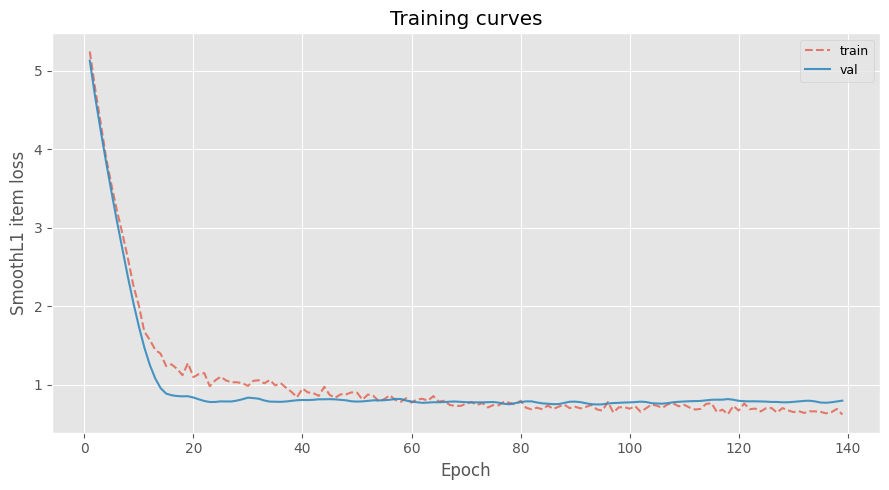

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], linestyle="--", alpha=0.7, label="train")
ax.plot(history_df["epoch"], history_df["val_loss"],   alpha=0.9,              label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("SmoothL1 item loss")
ax.set_title("Training curves")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Evaluation

Predictions are collected on held-out test patients. Per-item metrics (MAE, RMSE, R², Pearson r) are computed identically to the accepted paper. Total scores are reconstructed by summing per-item predictions.

In [32]:
def collect_predictions(artifact: dict) -> pd.DataFrame:
    rows  = []
    model = artifact["model"]
    model.eval()
    loader = make_loader(
        artifact["test_ids"], artifact["sensor_stats"], artifact["demo_stats"], shuffle=False
    )
    with torch.no_grad():
        for batch in loader:
            dev_batch = move_batch(batch)
            output    = model(dev_batch["x"], dev_batch["mask"], dev_batch["lengths"])
            sis_pred  = output["sis"].cpu().tolist()
            ohs_pred  = output["ohs"].cpu().tolist()
            for i in range(len(batch["patient"])):
                base = {
                    "patient"      : batch["patient"][i],
                    "clinical_time": pd.Timestamp(batch["clinical_time"][i]),
                    "history_days" : int(batch["lengths"][i]),
                }
                for name, truth, pred in zip(sis_targets, batch["sis"][i].tolist(), sis_pred[i]):
                    rows.append(base | {"outcome": "SIS", "item": name,
                                        "truth": float(truth), "prediction": float(pred)})
                for name, truth, pred in zip(ohs_targets, batch["ohs"][i].tolist(), ohs_pred[i]):
                    rows.append(base | {"outcome": "OHS", "item": name,
                                        "truth": float(truth), "prediction": float(pred)})
    return pd.DataFrame(rows)

def regression_metrics(frame: pd.DataFrame) -> pd.Series:
    y, p     = frame["truth"].to_numpy(), frame["prediction"].to_numpy()
    pearson  = np.corrcoef(y, p)[0, 1] if (len(y) > 1 and np.std(y) > 0 and np.std(p) > 0) else np.nan
    residual = y - p
    sst      = np.square(y - y.mean()).sum()
    r2       = 1 - np.square(residual).sum() / sst if sst > 0 else np.nan
    return pd.Series({"n": len(frame), "MAE": np.abs(residual).mean(),
                      "RMSE": np.sqrt(np.square(residual).mean()), "R2": r2, "Pearson": pearson})

def grouped_metrics(frame: pd.DataFrame, group_cols: list) -> pd.DataFrame:
    rows = []
    for keys, group in frame.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rows.append(dict(zip(group_cols, keys)) | regression_metrics(group).to_dict())
    return pd.DataFrame(rows).set_index(group_cols)


In [33]:
predictions = collect_predictions(artifact)

print("=== Overall per-item metrics ===")
display(grouped_metrics(predictions, ["outcome"]))

print("\n=== Per-item metrics ===")
display(grouped_metrics(predictions, ["outcome", "item"]))

print("\n=== Per-patient metrics ===")
display(grouped_metrics(predictions, ["patient", "outcome"]))


=== Overall per-item metrics ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,144.0,0.95439,1.164521,-0.281048,0.035897
SIS,72.0,1.30384,1.632279,-0.881732,0.281152



=== Per-item metrics ===


n       MAE      RMSE        R2   Pearson
outcome item                                                
OHS     ohs-01  12.0  0.796443  0.901883  0.334497  0.642203
        ohs-02  12.0  1.459016  1.512386 -0.328116 -0.537756
        ohs-03  12.0  1.644895  1.889735 -1.142659 -0.111208
        ohs-04  12.0  0.801444  0.941274 -0.099858  0.324716
        ohs-05  12.0  0.760060  0.819720 -1.764556 -0.164066
        ohs-06  12.0  0.487565  0.597904 -0.608699  0.037145
        ohs-07  12.0  1.227296  1.457894 -0.789857 -0.753201
        ohs-08  12.0  0.780319  0.933674 -0.673756  0.136589
        ohs-09  12.0  0.622296  0.734007 -0.521222  0.010948
        ohs-10  12.0  1.171787  1.320535 -0.402843  0.150586
        ohs-11  12.0  1.150214  1.400700 -0.125586  0.085858
        ohs-12  12.0  0.551349  0.666590  0.353684  0.654814
SIS     sis-01  12.0  1.064817  1.221895 -1.866612 -0.248546
        sis-02  12.0  0.741090  0.910080 -0.753931  0.204709
        sis-03  12.0  0.962590  1.112012 -0.935503  0.163801
        sis-04  12.0  1.213695  1.449967 -3.036617 -0.188306
        sis-05  12.0  1.876531  2.303951 -1.147134 -0.091264
        sis-06  12.0  1.964314  2.239993 -1.867182  0.216752


=== Per-patient metrics ===


n       MAE      RMSE        R2   Pearson
patient outcome                                              
6       OHS      48.0  0.992701  1.192104 -0.124397  0.113474
        SIS      24.0  0.813271  0.985957 -0.403347  0.415606
7       OHS      48.0  1.164137  1.387979 -1.534909 -0.370953
        SIS      24.0  1.146769  1.441190 -0.386290  0.517040
15      OHS      48.0  0.706334  0.848957  0.212260  0.490524
        SIS      24.0  1.951479  2.223480 -3.477463  0.032871

In [ ]:
pred_fname = DATA_DIR / f"test_predictions_seed{SEED}_x{TOP_X_SENSOR}_y{TOP_Y_DEMO}.csv"
predictions.to_csv(pred_fname, index=False)
print(f"Saved {len(predictions)} rows → {pred_fname}")


=== Total-score metrics (train raw) ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,48.0,2.626138,3.440442,0.853717,0.961826
SIS,48.0,1.255352,1.762955,0.791058,0.900456



=== Total-score metrics (val raw) ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,12.0,3.208934,4.238095,-1.184500,-0.050462
SIS,12.0,2.055212,2.737863,-0.349261,0.148094



=== Validation calibration parameters ===


...


=== Total-score metrics (test raw) ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,12.0,5.852346,7.587493,-1.575361,-0.15553
SIS,12.0,6.990207,8.039554,-3.365552,-0.04436



=== Total-score metrics (test calibrated from val) ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,12.0,5.445524,6.978526,-1.178557,-0.15553
SIS,12.0,5.123750,6.418328,-1.782397,-0.04436


Saved: scatter_train_raw.png


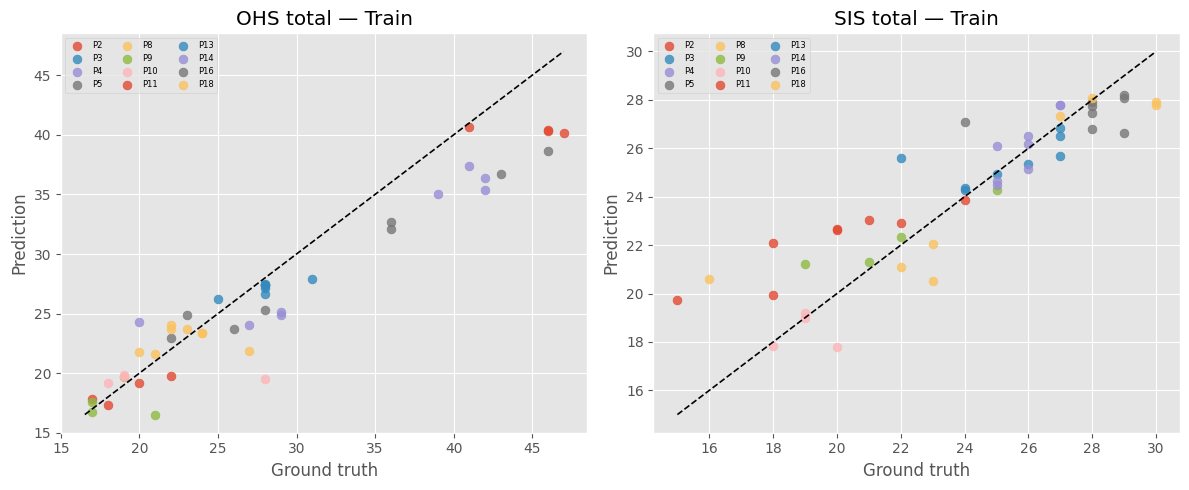

Saved: scatter_test_raw.png


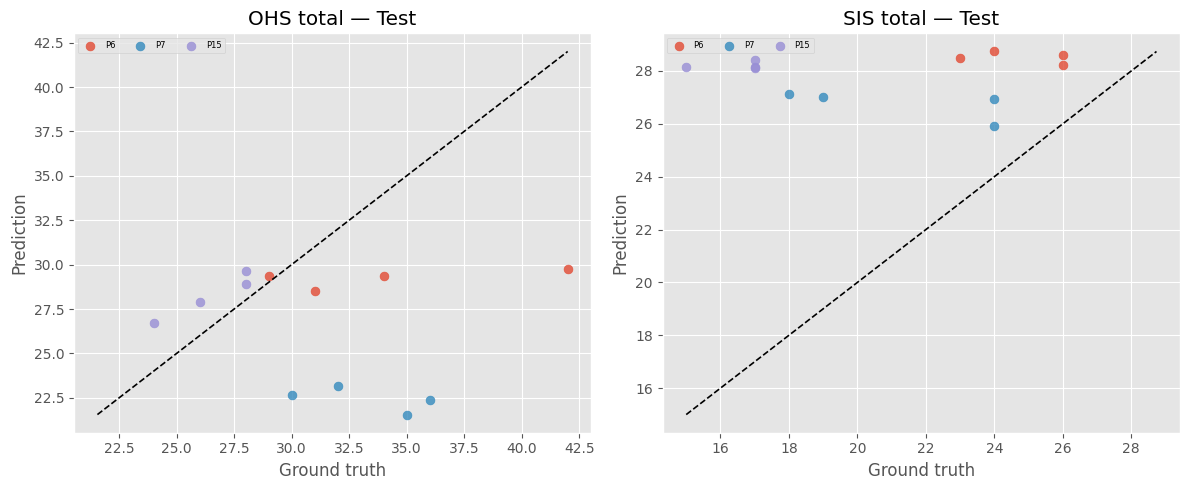

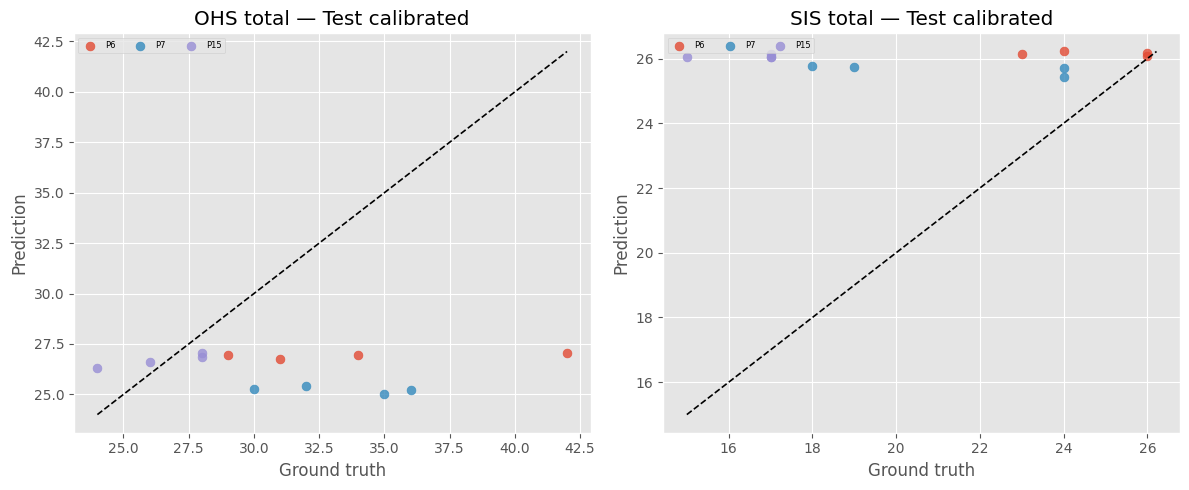

In [34]:
train_preds = collect_predictions({**artifact, "test_ids": artifact["train_ids"]})
val_preds = collect_predictions({**artifact, "test_ids": artifact["val_ids"]})

def totalize(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.groupby(
        ["patient", "clinical_time", "history_days", "outcome"], as_index=False
    )[["truth", "prediction"]].sum()

train_total = totalize(train_preds)
val_total = totalize(val_preds)
total_predictions = totalize(predictions)

def fit_total_calibration(frame: pd.DataFrame) -> dict:
    params = {}
    for outcome, sub in frame.groupby("outcome"):
        x = sub["prediction"].to_numpy(dtype=float)
        y = sub["truth"].to_numpy(dtype=float)
        x_var = np.var(x)
        if len(sub) < 3 or x_var <= 1e-8:
            slope, intercept = 1.0, 0.0
        else:
            slope = np.cov(x, y, ddof=0)[0, 1] / x_var
            slope = float(np.clip(slope, 0.25, 2.5))
            intercept = float(y.mean() - slope * x.mean())
        params[outcome] = {"slope": float(slope), "intercept": float(intercept)}
    return params

def apply_total_calibration(frame: pd.DataFrame, params: dict) -> pd.DataFrame:
    out = frame.copy()
    for outcome, p in params.items():
        mask = out["outcome"] == outcome
        out.loc[mask, "prediction"] = p["slope"] * out.loc[mask, "prediction"] + p["intercept"]
    return out

calibration_params = fit_total_calibration(val_total)
calibrated_total_predictions = apply_total_calibration(total_predictions, calibration_params)

print("=== Total-score metrics (train raw) ===")
display(grouped_metrics(train_total, ["outcome"]))

print()
print("=== Total-score metrics (val raw) ===")
display(grouped_metrics(val_total, ["outcome"]))

print()
print("=== Validation calibration parameters ===")
display(pd.DataFrame(calibration_params).T)

print()
print("=== Total-score metrics (test raw) ===")
display(grouped_metrics(total_predictions, ["outcome"]))

print()
print("=== Total-score metrics (test calibrated from val) ===")
display(grouped_metrics(calibrated_total_predictions, ["outcome"]))

outcomes = sorted(total_predictions["outcome"].unique())

plot_frames = [
    ("Train",       train_total,                   "scatter_train_raw.png"),
    ("Test",        total_predictions,             "scatter_test_raw.png"),
    ("Test calibrated", calibrated_total_predictions,  None),
]

for label, frame, fname in plot_frames:
    fig, axes = plt.subplots(1, len(outcomes), figsize=(6 * len(outcomes), 5))
    for ax, outcome in zip(axes, outcomes):
        sub = frame[frame["outcome"] == outcome]
        for patient, pf in sub.groupby("patient"):
            ax.scatter(pf["truth"], pf["prediction"], label=f"P{patient}", alpha=0.8, s=40)
        lo = min(sub["truth"].min(), sub["prediction"].min())
        hi = max(sub["truth"].max(), sub["prediction"].max())
        ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.2, linestyle="--")
        ax.set_title(f"{outcome} total — {label}")
        ax.set_xlabel("Ground truth")
        ax.set_ylabel("Prediction")
        ax.legend(fontsize=6, ncol=3, loc="upper left")
    plt.tight_layout()
    if fname:
        plt.savefig(DATA_DIR / fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()


Train raw | OHS:  raw mean=1.792,  raw std=2.968,  normalised mean=0.604
Train raw | SIS:  raw mean=-0.325,  raw std=1.751,  normalised mean=-0.185


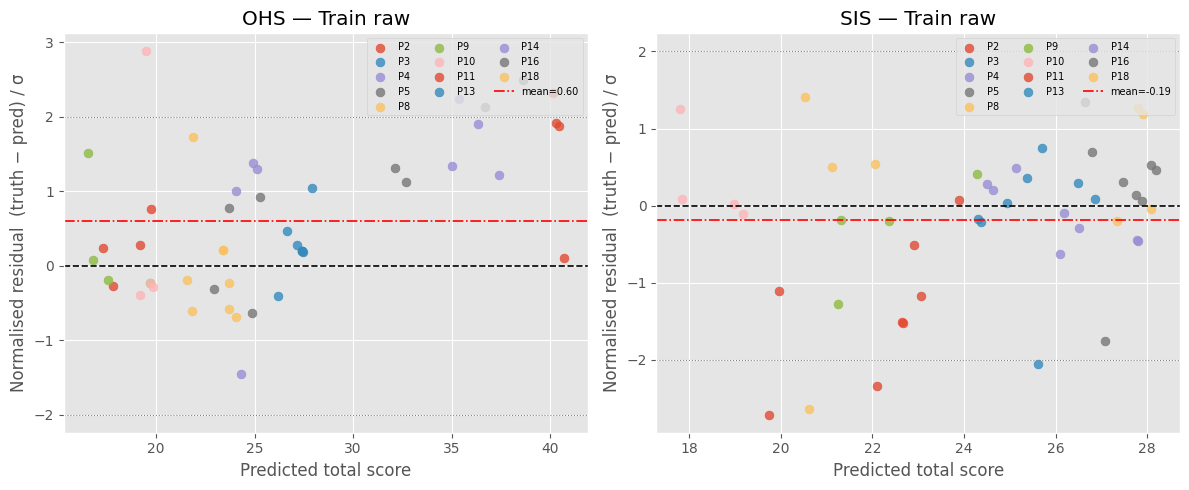

Saved: residuals_train_raw.png
Test raw | OHS:  raw mean=4.586,  raw std=6.314,  normalised mean=0.726
Test raw | SIS:  raw mean=-6.990,  raw std=4.148,  normalised mean=-1.685


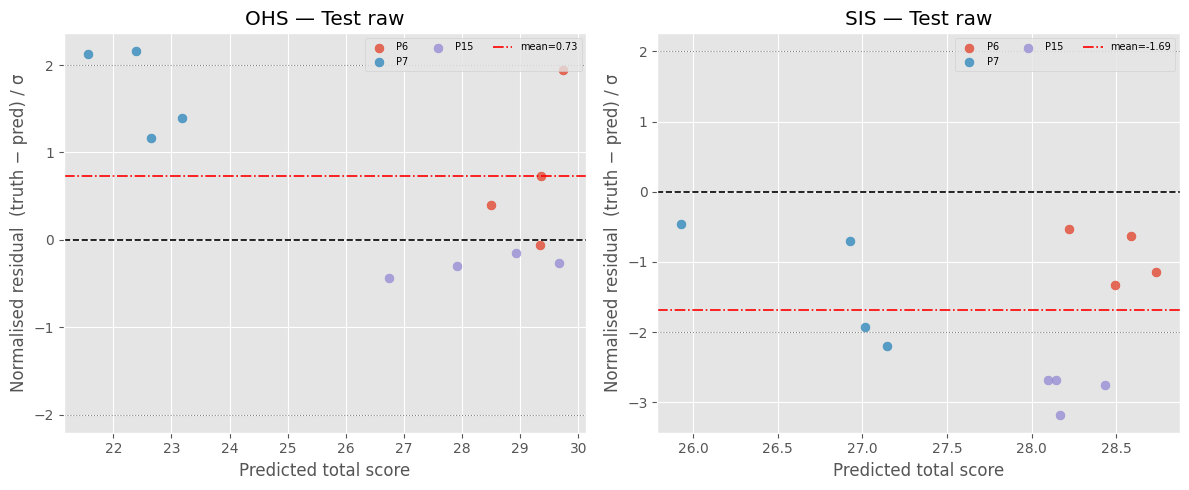

Saved: residuals_test_raw.png


In [35]:
for label, frame, fname in [
    ("Train raw", train_total,       "residuals_train_raw.png"),
    ("Test raw",  total_predictions, "residuals_test_raw.png"),
]:
    fig, axes = plt.subplots(1, len(outcomes), figsize=(6 * len(outcomes), 5))
    for ax, outcome in zip(axes, outcomes):
        sub = frame[frame["outcome"] == outcome].copy()
        sub["residual"] = sub["truth"] - sub["prediction"]
        std  = sub["residual"].std()
        mean = sub["residual"].mean()
        sub["residual_norm"] = sub["residual"] / std if std > 0 else sub["residual"]
        mean_norm = mean / std if std > 0 else mean
        for patient, pf in sub.groupby("patient"):
            ax.scatter(pf["prediction"], pf["residual_norm"],
                       label=f"P{patient}", alpha=0.8, s=40)
        ax.axhline(0,         color="black", linewidth=1.2, linestyle="--")
        ax.axhline( 2,        color="grey",  linewidth=0.8, linestyle=":")
        ax.axhline(-2,        color="grey",  linewidth=0.8, linestyle=":")
        ax.axhline(mean_norm, color="red",   linewidth=1.2, linestyle="-.",
                   label=f"mean={mean_norm:.2f}")
        ax.set_title(f"{outcome} — {label}")
        ax.set_xlabel("Predicted total score")
        ax.set_ylabel("Normalised residual  (truth \u2212 pred) / \u03c3")
        ax.legend(fontsize=7, ncol=3, loc="upper right")
        print(f"{label} | {outcome}:  raw mean={mean:.3f},  raw std={std:.3f},  normalised mean={mean_norm:.3f}")
    plt.tight_layout()
    plt.savefig(DATA_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


In [36]:
print("=== Total-score spread (train raw) ===")
display(train_total.groupby("outcome")[["truth", "prediction"]].agg(["mean", "std", "min", "max"]))

print()
print("=== Total-score spread (val raw) ===")
display(val_total.groupby("outcome")[["truth", "prediction"]].agg(["mean", "std", "min", "max"]))

print()
print("=== Total-score spread (test raw) ===")
display(total_predictions.groupby("outcome")[["truth", "prediction"]].agg(["mean", "std", "min", "max"]))

print()
print("=== Total-score spread (test calibrated from val) ===")
display(calibrated_total_predictions.groupby("outcome")[["truth", "prediction"]].agg(["mean", "std", "min", "max"]))


=== Total-score spread (train raw) ===


truth                       prediction                       \
              mean       std   min   max       mean       std        min   
outcome                                                                    
OHS      28.145833  9.090537  17.0  47.0  26.353907  7.124752  16.522095   
SIS      24.000000  3.897626  15.0  30.0  24.324514  3.070701  17.797706   

                    
               max  
outcome             
OHS      40.694170  
SIS      28.196804


=== Total-score spread (val raw) ===


truth                       prediction                      \
              mean       std   min   max       mean      std        min   
outcome                                                                   
OHS      26.333333  2.994945  22.0  31.0  26.838266  3.06901  22.488440   
SIS      25.666667  2.461830  22.0  29.0  26.807679  1.27529  24.772672   

                    
               max  
outcome             
OHS      31.509634  
SIS      28.657013


=== Total-score spread (test raw) ===


truth                       prediction                       \
              mean       std   min   max       mean       std        min   
outcome                                                                    
OHS      31.250000  4.938255  24.0  42.0  26.664111  3.240068  21.556254   
SIS      20.833333  4.018895  15.0  26.0  27.823540  0.863580  25.928530   

                    
               max  
outcome             
OHS      29.730561  
SIS      28.735996


=== Total-score spread (test calibrated from val) ===


truth                       prediction                       \
              mean       std   min   max       mean       std        min   
outcome                                                                    
OHS      31.250000  4.938255  24.0  42.0  26.289795  0.810017  25.012830   
SIS      20.833333  4.018895  15.0  26.0  25.957084  0.246882  25.415334   

                    
               max  
outcome             
OHS      27.056407  
SIS      26.217938

In [37]:
for label, frame in [("train raw", train_total), ("val raw", val_total), ("test raw", total_predictions), ("test calibrated", calibrated_total_predictions)]:
    print(f"=== Calibration slope ({label}) ===")
    for outcome in outcomes:
        sub = frame[frame["outcome"] == outcome]
        x = sub["prediction"].to_numpy(dtype=float)
        y = sub["truth"].to_numpy(dtype=float)
        x_var = np.var(x)
        slope = np.cov(x, y, ddof=0)[0, 1] / x_var if x_var > 0 else np.nan
        intercept = y.mean() - slope * x.mean() if np.isfinite(slope) else np.nan
        print(outcome, "slope:", slope, "intercept:", intercept)
    print()


=== Calibration slope (train raw) ===
OHS slope: 1.2272029136043554 intercept: -4.195757805290182
SIS slope: 1.1429440704934168 intercept: -3.80155910821955

=== Calibration slope (val raw) ===
OHS slope: -0.049244427944405166 intercept: 27.654968397602367
SIS slope: 0.28588233778603744 intercept: 18.002824809438533

=== Calibration slope (test raw) ===
OHS slope: -0.23704672912829494 intercept: 37.57064032552198
SIS slope: -0.20643983690054787 intercept: 26.57722048975169

=== Calibration slope (test calibrated) ===
OHS slope: -0.9481869165131795 intercept: 56.17763925070298
SIS slope: -0.7221146941055487 intercept: 39.57732482005506



## Learned Feature Gate Weights

Inspecting the final gate weights shows which features the model emphasised for each target after training — useful for comparing with the initial SHAP priors.

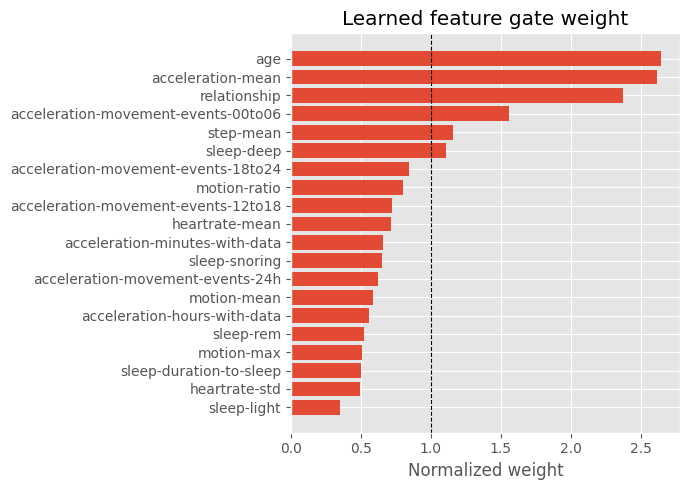

,Gate_learned
feature,
age,2.649
acceleration-mean,2.618
relationship,2.372
acceleration-movement-events-00to06,1.561
step-mean,1.160
sleep-deep,1.109
acceleration-movement-events-18to24,0.842
motion-ratio,0.802
acceleration-movement-events-12to18,0.724


In [38]:
model = artifact["model"]
with torch.no_grad():
    gate_w = torch.nn.functional.softplus(model.feature_gate.raw).cpu().numpy()
gate_w = gate_w / gate_w.mean()

learned_df = pd.DataFrame({
    "feature"     : input_cols,
    "Gate_learned": gate_w,
})

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
s = learned_df.set_index("feature")["Gate_learned"].sort_values(ascending=False)
ax.barh(s.index[::-1], s.values[::-1])
ax.set_title("Learned feature gate weight")
ax.set_xlabel("Normalized weight")
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

display(learned_df.set_index("feature").sort_values("Gate_learned", ascending=False).round(3))


In [ ]:
results_dir = Path(DATA_DIR / "results")
pred_files  = sorted(results_dir.glob("test_predictions_seed*.csv"))
print(f"Found {len(pred_files)} seed files:")
for f in pred_files:
    print(f"  {f.name}")

all_seeds = pd.concat([pd.read_csv(f) for f in pred_files], ignore_index=True)

ensemble_predictions = (
    all_seeds
    .groupby(["patient", "clinical_time", "history_days", "outcome", "item"], as_index=False)
    .agg(truth=("truth", "first"), prediction=("prediction", "mean"))
)
print(f"\nEnsemble: {len(ensemble_predictions)} rows averaged over {len(pred_files)} seeds")
display(ensemble_predictions.head(10))


In [ ]:
print("=== Ensemble: overall per-item metrics ===")
display(grouped_metrics(ensemble_predictions, ["outcome"]))

print("\n=== Ensemble: per-item metrics ===")
display(grouped_metrics(ensemble_predictions, ["outcome", "item"]))

print("\n=== Ensemble: per-patient metrics ===")
display(grouped_metrics(ensemble_predictions, ["patient", "outcome"]))


In [ ]:
ensemble_total = totalize(ensemble_predictions)

print("=== Ensemble: total-score metrics ===")
display(grouped_metrics(ensemble_total, ["outcome"]))

outcomes_ens = sorted(ensemble_total["outcome"].unique())

fig, axes = plt.subplots(1, len(outcomes_ens), figsize=(6 * len(outcomes_ens), 5))
for ax, outcome in zip(axes, outcomes_ens):
    sub = ensemble_total[ensemble_total["outcome"] == outcome]
    for patient, pf in sub.groupby("patient"):
        ax.scatter(pf["truth"], pf["prediction"], label=f"P{patient}", alpha=0.8, s=40)
    lo = min(sub["truth"].min(), sub["prediction"].min())
    hi = max(sub["truth"].max(), sub["prediction"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.2, linestyle="--")
    ax.set_title(f"{outcome} total — Ensemble test")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Prediction")
    ax.legend(fontsize=6, ncol=3, loc="upper left")
plt.tight_layout()
plt.savefig(DATA_DIR / "scatter_ensemble_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: scatter_ensemble_test.png")

fig, axes = plt.subplots(1, len(outcomes_ens), figsize=(6 * len(outcomes_ens), 5))
for ax, outcome in zip(axes, outcomes_ens):
    sub = ensemble_total[ensemble_total["outcome"] == outcome].copy()
    sub["residual"] = sub["truth"] - sub["prediction"]
    std       = sub["residual"].std()
    mean      = sub["residual"].mean()
    sub["residual_norm"] = sub["residual"] / std if std > 0 else sub["residual"]
    mean_norm = mean / std if std > 0 else mean
    for patient, pf in sub.groupby("patient"):
        ax.scatter(pf["prediction"], pf["residual_norm"], label=f"P{patient}", alpha=0.8, s=40)
    ax.axhline(0,         color="black", linewidth=1.2, linestyle="--")
    ax.axhline( 2,        color="grey",  linewidth=0.8, linestyle=":")
    ax.axhline(-2,        color="grey",  linewidth=0.8, linestyle=":")
    ax.axhline(mean_norm, color="red",   linewidth=1.2, linestyle="-.", label=f"mean={mean_norm:.2f}")
    ax.set_title(f"{outcome} — Ensemble residuals")
    ax.set_xlabel("Predicted total score")
    ax.set_ylabel("Normalised residual  (truth − pred) / σ")
    ax.legend(fontsize=7, ncol=3, loc="upper right")
    print(f"{outcome}:  mean={mean:.3f},  std={std:.3f},  normalised mean={mean_norm:.3f}")
plt.tight_layout()
plt.savefig(DATA_DIR / "residuals_ensemble_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: residuals_ensemble_test.png")
